# A simple notebook to perform binary classification on a comprehensive pokemon dataset to predict whether a given specimen is legendary or not
# Dataset taken from Kaggle - https://www.kaggle.com/datasets/rounakbanik/pokemon

In [1]:
# ----------------------------------------------------------------------------------------
# Import basic libraries
# ----------------------------------------------------------------------------------------
import sys
import io
import pickle

import numpy as np
import pandas as pd
import ast

# ----------------------------------------------------------------------------------------
# Import graphic libraries
# ----------------------------------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------------------------------------------------------------------
# Import scikit-learn libraries
# ----------------------------------------------------------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Project Constants

In [2]:
# ----------------------------------------------------------------------------------------
# global constants
# ----------------------------------------------------------------------------------------
random_seed = 42

# ----------------------------------------------------------------------------------------
# dataset constants
# ----------------------------------------------------------------------------------------
dataset_cvs_filename = "pokemon.csv"
dataset_cvs_delimiter_char = ','
dataset_cvs_num_rows_read = None # specify 'None' if want to read whole file

label_classification = 'is_legendary'

# ----------------------------------------------------------------------------------------
# machine learning constants
# ----------------------------------------------------------------------------------------
common_cv_folds = 5
common_scoring_metric = 'accuracy'

# train test split constants
test_train_split_rate = 0.2
test_train_split_random_state = random_seed

# logistic regression hyper-parameters
lg_random_state = random_seed
lg_verbose = 1

# the following values are default ones
# these will be candidates to be optimized with grid sreach
lg_penalty = 'l2'
lg_l1_ratio = 0.0

# grid search hyper-parameters for logistic regression optimization
lg_grid_search_cv_folds = common_cv_folds
lg_grid_search_scoring = common_scoring_metric
lg_grid_search_random_state = random_seed
lg_grid_search_verbose = 0

# random forrest hyper-parameters
rf_random_state = random_seed
rf_verbose = 1

# the following values are default ones
# these wil be candidates to be optimized with grid search
rf_n_estimators = 100
rf_max_depth = None
rf_min_samples_split = 2

# grid search hyper-parameters for random forrest optimization
rf_grid_search_cv_folds = common_cv_folds
rf_grid_search_scoring = common_scoring_metric
rf_grid_search_random_state = random_seed
rf_grid_search_verbose = 0

# XGBoost hyper-parameters
xgboost_random_state = random_seed
xgboost_verbose = 1

# the following values are default ones
# these wil be candidates to be optimized with grid search
xgbost_n_estimators = 100
xg_boost_max_depth = 3
xgboost_min_samples_split = 2

# Grid search hypr-parameters for XGBoost optimization
xgboost_grid_search_cv_folds = common_cv_folds
xgboost_grid_search_scoring = common_scoring_metric
xgboost_grid_search_random_state = random_seed
xgboost_grid_search_verbose = 0

## Project Utility Routines

In [3]:
# Display Dataset Distribution Graphs (histogram/bar graph) of column data
def plotPerColumnDistribution(df, nGraphShown, nGraphPerRow):
    nunique = df.nunique()
    df = df[[col for col in df if nunique[col] > 1 and nunique[col] < 50]] # For displaying purposes, pick columns that have between 1 and 50 unique values
    nRow, nCol = df.shape
    columnNames = list(df)
    nGraphRow = int((nCol + nGraphPerRow - 1) / nGraphPerRow)
    plt.figure(num = None, figsize = (6 * nGraphPerRow, 8 * nGraphRow), dpi = 80, facecolor = 'w', edgecolor = 'k')
    for i in range(min(nCol, nGraphShown)):
        plt.subplot(nGraphRow, nGraphPerRow, i + 1)
        columnDf = df.iloc[:, i]
        if (not np.issubdtype(type(columnDf.iloc[0]), np.number)):
            valueCounts = columnDf.value_counts()
            valueCounts.plot.bar()
        else:
            columnDf.hist()
        plt.ylabel('counts')
        plt.xticks(rotation = 90)
        plt.title(f'{columnNames[i]} (column {i})')
    plt.tight_layout(pad = 1.0, w_pad = 1.0, h_pad = 1.0)
    plt.show()

In [4]:
# Dataset Correlation matrix
def plotCorrelationMatrix(df, graphWidth, title):
    df = df.dropna(axis='columns') # drop columns with NaN
    df = df[[col for col in df if df[col].nunique() > 1]] # keep columns where there are more than 1 unique values
    if df.shape[1] < 2:
        print(f'No correlation plots shown: The number of non-NaN or constant columns ({df.shape[1]}) is less than 2')
        return
    corr = df.corr()
    plt.figure(num=None, figsize=(graphWidth, graphWidth), dpi=80, facecolor='w', edgecolor='k')
    corrMat = plt.matshow(corr, fignum = 1)
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.gca().xaxis.tick_bottom()
    plt.colorbar(corrMat)
    plt.title(f'Correlation Matrix for {title}', fontsize=15)
    plt.show()

In [5]:
# utility to estimate the model size on disk
def estimate_model_size(model):
    buffer = io.BytesIO()
    pickle.dump(model, buffer)

    size_bytes = buffer.tell()
    size_kb = size_bytes / 1024

    return size_kb

## Dataset Loading and Exploration

In [6]:
# load dataset from cvs file
try:
    df = pd.read_csv(dataset_cvs_filename, delimiter=dataset_cvs_delimiter_char, nrows = dataset_cvs_num_rows_read)
    num_rows, num_columns = df.shape
except Exception as e:
    print("⚠️ Unable to load Pokemon dataset.")
    exit(0)

print(f"✅ Pokemon dataset has been succefully loaded: there are {num_rows} rows and {num_columns} columns.\n")

✅ Pokemon dataset has been succefully loaded: there are 801 rows and 41 columns.



In [7]:
# sanity checks for the classification column
df_labels = df[label_classification]

if df_labels.isnull().sum() != 0:
    print(f"⚠️ The Pokemon dataset is not actionable, there are null value in the '{label_classification}' column.")
    exit(0)
if df_labels.dtype != 'int64':
    print(f"⚠️ The Pokemon dataset is not actionable, there are null value in the '{label_classification}' column.")
    exit(0)

num_pokemon_legendary = df_labels.value_counts().get(1)
num_pokemon_non_legendary = df_labels.value_counts().get(0)

if num_pokemon_legendary + num_pokemon_non_legendary != len(df):
    print(f"⚠️ The Pokemon dataset is not actionable, the '{label_classification}' column contains values different than zero or one.")

print(f"✅ There are {num_pokemon_legendary} legendary pokemon in the dataset ({num_pokemon_legendary/len(df)*100:.2f}%).")

✅ There are 70 legendary pokemon in the dataset (8.74%).


In [8]:
# display first rows
df.head()

,abilities,against_bug,against_dark,against_dragon,against_electric,against_fairy,against_fight,against_fire,against_flying,against_ghost,...,percentage_male,pokedex_number,sp_attack,sp_defense,speed,type1,type2,weight_kg,generation,is_legendary
0,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,1,65,65,45,grass,poison,6.9,1,0
1,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,2,80,80,60,grass,poison,13.0,1,0
2,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,3,122,120,80,grass,poison,100.0,1,0
3,"['Blaze', 'Solar Power']",0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,...,88.1,4,60,50,65,fire,NaN,8.5,1,0
4,"['Blaze', 'Solar Power']",0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,...,88.1,5,80,65,80,fire,NaN,19.0,1,0


In [9]:
# features
df_features = df.drop(label_classification, axis=1)

# display numerical and categorical columns 
numerical_features = df_features.select_dtypes(include=['int64', 'float64']).columns
print(f"Numerical Features: {numerical_features}.")

categorical_features = df_features.select_dtypes(include=['object']).columns
print(f"Categorical Features: {categorical_features}.")

Numerical Features: Index(['against_bug', 'against_dark', 'against_dragon', 'against_electric',
       'against_fairy', 'against_fight', 'against_fire', 'against_flying',
       'against_ghost', 'against_grass', 'against_ground', 'against_ice',
       'against_normal', 'against_poison', 'against_psychic', 'against_rock',
       'against_steel', 'against_water', 'attack', 'base_egg_steps',
       'base_happiness', 'base_total', 'defense', 'experience_growth',
       'height_m', 'hp', 'percentage_male', 'pokedex_number', 'sp_attack',
       'sp_defense', 'speed', 'weight_kg', 'generation'],
      dtype='object').
Categorical Features: Index(['abilities', 'capture_rate', 'classfication', 'japanese_name', 'name',
       'type1', 'type2'],
      dtype='object').


## First observations from dataset exploration: 
    - 'japanese_name', 'name' : colmuns will be dropped, japanaese names or names should not influence legendary classification
    - 'pokedex_number' : column will be dropped, index of appearance in pokedex (pokemon encyclodepia) should not influence legendary classification 
    - 'capture_rate' : need to check column values, should this be a numerical type? 
    - 'abilities' : multi-values string describing 'features' of pokemons. These information need therefore special processing and be transformed into dataframe columns to be taken into account for classification

In [10]:
# Explore the null values in the dataset
df.isnull().sum().sort_values(ascending=False)

type2                384
percentage_male       98
weight_kg             20
height_m              20
name                   0
capture_rate           0
classfication          0
defense                0
experience_growth      0
hp                     0
japanese_name          0
abilities              0
base_happiness         0
pokedex_number         0
sp_attack              0
sp_defense             0
speed                  0
type1                  0
generation             0
base_total             0
base_egg_steps         0
against_bug            0
attack                 0
against_dark           0
against_dragon         0
against_electric       0
against_fairy          0
against_fight          0
against_fire           0
against_flying         0
against_ghost          0
against_grass          0
against_ground         0
against_ice            0
against_normal         0
against_poison         0
against_psychic        0
against_rock           0
against_steel          0
against_water          0


## Second observations from dataset exploration: 
    - 'type2' : the colmun will be dropped, this is a sub-type ('string' type) of pokemon so any imputation strategy is irrelevant
    - 'percentage_male' : null values will be replaced with a neutral value, i.e. 50.0
    - 'weight_kg', 'height_m' : null value wil be replaced with average value

In [11]:
# drop unactionable columns for prediction
actionable_df_features = df_features.drop(['japanese_name', 'name', 'type2', 'pokedex_number'], axis=1)
actionable_num_rows, actionable_num_columns = actionable_df_features.shape

print(f"✅ The Pokemon actionable dataset has {actionable_num_columns} feature colmuns.")

# recompute numerical and categorical features 
actionable_numerical_features = actionable_df_features.select_dtypes(include=['int64', 'float64']).columns
print(f"Actionable numerical Features: {actionable_numerical_features}.")

actionable_categorical_features = actionable_df_features.select_dtypes(include=['object']).columns
print(f"Actionable categorical Features: {actionable_categorical_features}.")

✅ The Pokemon actionable dataset has 36 feature colmuns.
Actionable numerical Features: Index(['against_bug', 'against_dark', 'against_dragon', 'against_electric',
       'against_fairy', 'against_fight', 'against_fire', 'against_flying',
       'against_ghost', 'against_grass', 'against_ground', 'against_ice',
       'against_normal', 'against_poison', 'against_psychic', 'against_rock',
       'against_steel', 'against_water', 'attack', 'base_egg_steps',
       'base_happiness', 'base_total', 'defense', 'experience_growth',
       'height_m', 'hp', 'percentage_male', 'sp_attack', 'sp_defense', 'speed',
       'weight_kg', 'generation'],
      dtype='object').
Actionable categorical Features: Index(['abilities', 'capture_rate', 'classfication', 'type1'], dtype='object').


In [12]:
# check unexpected typed column 'capture_rate' : type is 'object' but should it be 'int64' or 'float64' instead?
df_capture_rate = actionable_df_features['capture_rate'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 801 entries, 0 to 800
Series name: capture_rate
Non-Null Count  Dtype 
--------------  ----- 
801 non-null    object
dtypes: object(1)
memory usage: 6.4+ KB


In [13]:
# check wether 'capture_rate' values are actually numerical, if not replace them by None
for idx in range(0, len(actionable_df_features['capture_rate'])):
    try:
        val = float(actionable_df_features['capture_rate'].at[idx])
    except Exception as e:
        print(f"⚠️ An anomaly has been found in the 'capture_rate' column at index '{idx}': value '{actionable_df_features['capture_rate'].at[idx]}' has been replaced by 'None'.")
        actionable_df_features['capture_rate'].at[idx] = None

print(f"⚠️ Number of anomalies found : {actionable_df_features['capture_rate'].isnull().sum()}")

⚠️ An anomaly has been found in the 'capture_rate' column at index '773': value '30 (Meteorite)255 (Core)' has been replaced by 'None'.
⚠️ Number of anomalies found : 1


In [14]:
# now convert 'capture_rate' column to float64
actionable_df_features['capture_rate'] =  actionable_df_features['capture_rate'].astype('float64')

In [15]:
# recompute numerical and categorical features 
numerical_features = actionable_df_features.select_dtypes(include=['int64', 'float64']).columns
print(f"Numerical Features: {numerical_features}.")

categorical_features = actionable_df_features.select_dtypes(include=['object']).columns
print(f"Categorical Features: {categorical_features}.")

Numerical Features: Index(['against_bug', 'against_dark', 'against_dragon', 'against_electric',
       'against_fairy', 'against_fight', 'against_fire', 'against_flying',
       'against_ghost', 'against_grass', 'against_ground', 'against_ice',
       'against_normal', 'against_poison', 'against_psychic', 'against_rock',
       'against_steel', 'against_water', 'attack', 'base_egg_steps',
       'base_happiness', 'base_total', 'capture_rate', 'defense',
       'experience_growth', 'height_m', 'hp', 'percentage_male', 'sp_attack',
       'sp_defense', 'speed', 'weight_kg', 'generation'],
      dtype='object').
Categorical Features: Index(['abilities', 'classfication', 'type1'], dtype='object').


In [16]:
# Explore the null values in the dataset
actionable_df_features.isnull().sum().sort_values(ascending=False)

percentage_male      98
height_m             20
weight_kg            20
capture_rate          1
experience_growth     0
base_egg_steps        0
base_happiness        0
base_total            0
classfication         0
defense               0
abilities             0
against_bug           0
hp                    0
sp_attack             0
sp_defense            0
speed                 0
type1                 0
attack                0
against_water         0
against_steel         0
against_flying        0
against_dark          0
against_dragon        0
against_electric      0
against_fairy         0
against_fight         0
against_fire          0
against_ghost         0
against_rock          0
against_grass         0
against_ground        0
against_ice           0
against_normal        0
against_poison        0
against_psychic       0
generation            0
dtype: int64

## Third observation from dataset exploration: 
    - 'capture_rate' : null values will be replaced with a neutral value, i.e. mean

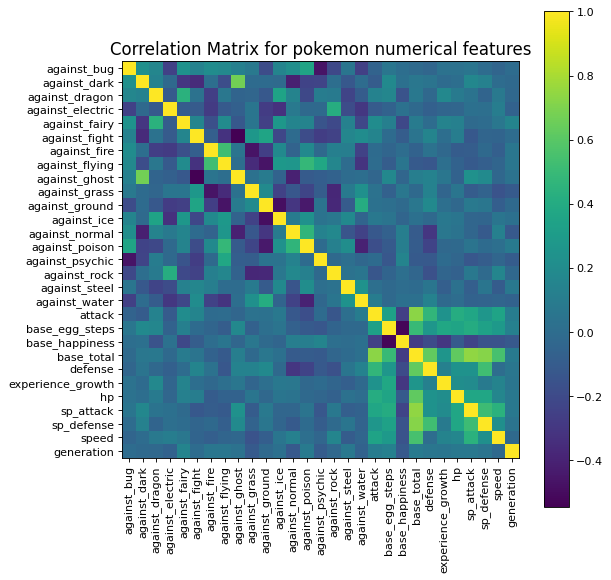

In [17]:
# Display correlation matrix of numerical features
plotCorrelationMatrix(actionable_df_features.drop(columns=categorical_features), 8, "pokemon numerical features")

In [18]:
# Now explore the 'abilities' column
actionable_df_features['abilities']

0      ['Overgrow', 'Chlorophyll']
1      ['Overgrow', 'Chlorophyll']
2      ['Overgrow', 'Chlorophyll']
3         ['Blaze', 'Solar Power']
4         ['Blaze', 'Solar Power']
                  ...             
796                ['Beast Boost']
797                ['Beast Boost']
798                ['Beast Boost']
799                ['Prism Armor']
800                 ['Soul-Heart']
Name: abilities, Length: 801, dtype: object

In [19]:
num_rows, num_columns = actionable_df_features.shape
print(f"Before the 'abilities' transformation, Pokemon dataset contains {num_rows} rows and {num_columns} columns.")

# Explode the multi-abilities string values into lists of abilities 
actionable_df_features['abilities'] = actionable_df_features['abilities'].apply(ast.literal_eval)

# Generate a dataframe where each column represents a unique abiltity found in the previous 'abilities' column
# join('|') temporarily transforms a list into a '|' delimiter separated string
# get_dummies finds all unique elements separately and builds columns with 0 or 1 values
new_abilities = actionable_df_features['abilities'].str.join('|').str.get_dummies()

# Drop the 'abilities' original column 
actionable_df_features = actionable_df_features.drop(labels=['abilities'], axis=1)

# concatenate the new dataframe 
actionable_df_features = pd.concat([actionable_df_features, new_abilities], axis=1)

num_rows, num_columns = actionable_df_features.shape
print(f"✅ After the 'abilities' transformation, actionable Pokemon dataset contains {num_rows} rows and {num_columns} columns.")

Before the 'abilities' transformation, Pokemon dataset contains 801 rows and 36 columns.
✅ After the 'abilities' transformation, actionable Pokemon dataset contains 801 rows and 262 columns.


In [20]:
actionable_df_features.head()

,against_bug,against_dark,against_dragon,against_electric,against_fairy,against_fight,against_fire,against_flying,against_ghost,against_grass,...,Water Absorb,Water Bubble,Water Compaction,Water Veil,Weak Armor,White Smoke,Wimp Out,Wonder Guard,Wonder Skin,Zen Mode
0,1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,0.25,...,0,0,0,0,0,0,0,0,0,0
1,1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,0.25,...,0,0,0,0,0,0,0,0,0,0
2,1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,0.25,...,0,0,0,0,0,0,0,0,0,0
3,0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,0.50,...,0,0,0,0,0,0,0,0,0,0
4,0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,0.50,...,0,0,0,0,0,0,0,0,0,0


In [21]:
# recompute numerical and categorical features 
numerical_features = actionable_df_features.select_dtypes(include=['int64', 'float64']).columns
print(f"Numerical Features ({len(numerical_features)}): {numerical_features}.")

categorical_features = actionable_df_features.select_dtypes(include=['object']).columns
print(f"Categorical Features ({len(categorical_features)}): {categorical_features}.")

Numerical Features (260): Index(['against_bug', 'against_dark', 'against_dragon', 'against_electric',
       'against_fairy', 'against_fight', 'against_fire', 'against_flying',
       'against_ghost', 'against_grass',
       ...
       'Water Absorb', 'Water Bubble', 'Water Compaction', 'Water Veil',
       'Weak Armor', 'White Smoke', 'Wimp Out', 'Wonder Guard', 'Wonder Skin ',
       'Zen Mode'],
      dtype='object', length=260).
Categorical Features (2): Index(['classfication', 'type1'], dtype='object').


In [22]:
# Explore the null values in the dataset
actionable_df_features.isnull().sum().sort_values(ascending=False)

percentage_male    98
height_m           20
weight_kg          20
capture_rate        1
against_bug         0
                   ..
Galvanize           0
Gluttony            0
Gooey               0
Grass Pelt          0
Zen Mode            0
Length: 262, dtype: int64

## Summary of Observations
    - 'height_m', 'weight_kg', 'capture_rate' : replace null value by mean of column
    - 'percentage_male' : replace null value by neutral value : 50.0

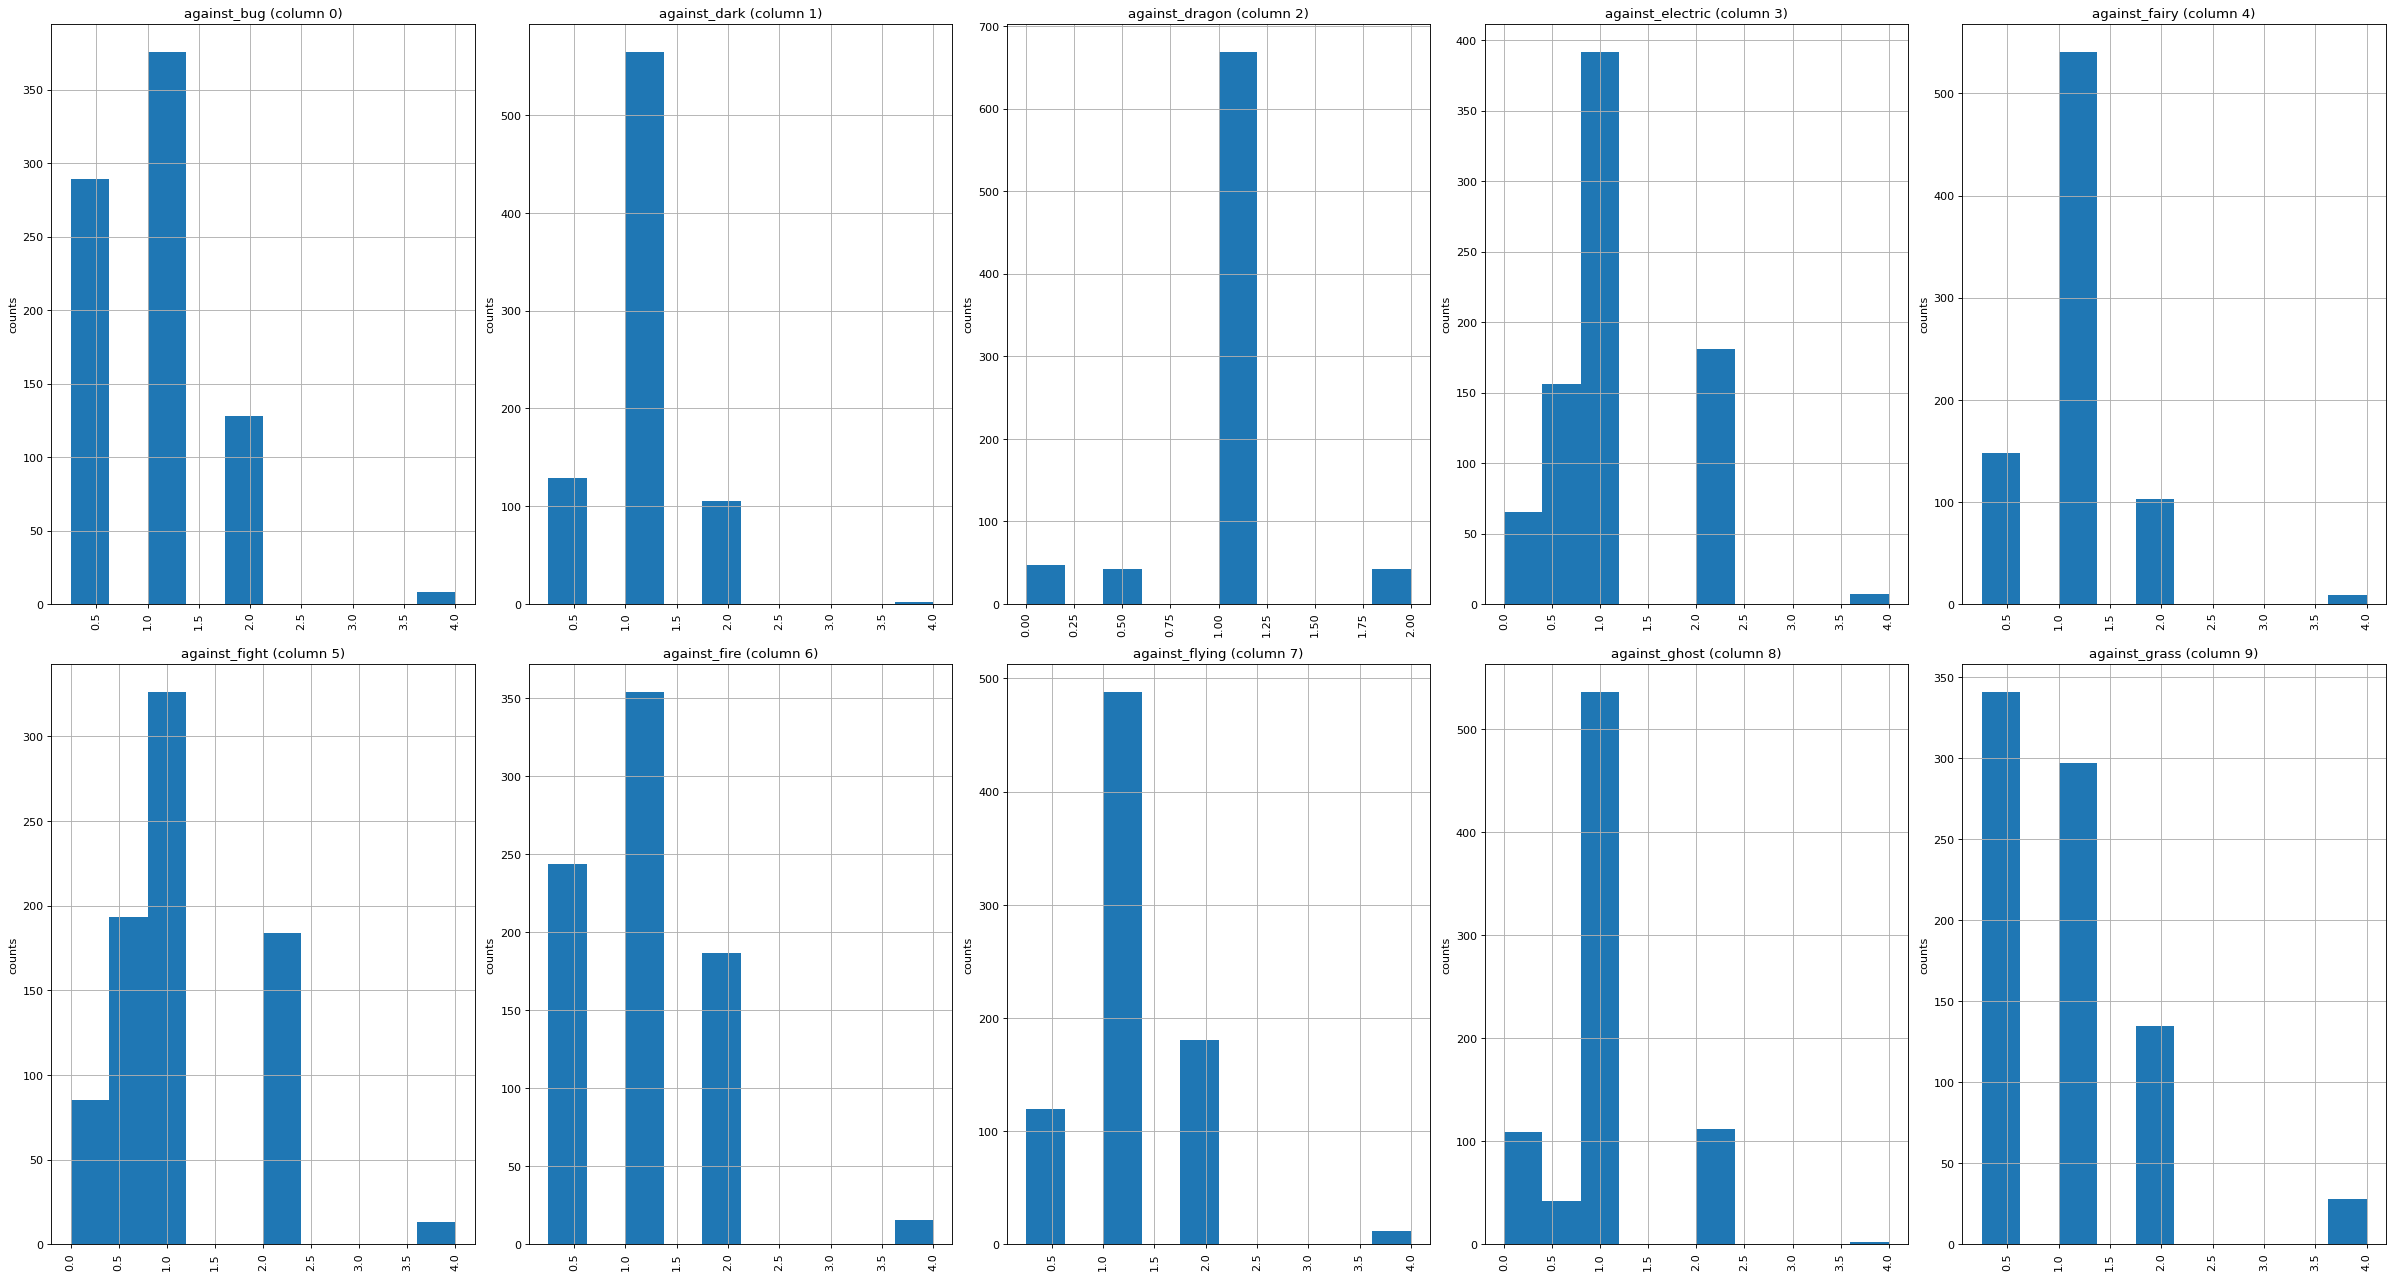

In [23]:
# show distribution of a few columns
plotPerColumnDistribution(actionable_df_features, 10, 5)

In [24]:
# dataframe cleaned and preped for training 
X = actionable_df_features
y = df_labels

num_rows, num_columns = X.shape
print(f"✅ The Pokemon dataset has been cleaned and prepared for training, it contains {num_rows} rows and {num_columns} columns.")

# recompute numerical and categorical features 
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns
print(f"    Numerical Features ({len(numerical_features)}): {numerical_features.to_list()}.")

categorical_features = X.select_dtypes(include=['object']).columns
print(f"    Categorical Features ({len(categorical_features)}): {categorical_features.to_list()}.")

✅ The Pokemon dataset has been cleaned and prepared for training, it contains 801 rows and 262 columns.
    Numerical Features (260): ['against_bug', 'against_dark', 'against_dragon', 'against_electric', 'against_fairy', 'against_fight', 'against_fire', 'against_flying', 'against_ghost', 'against_grass', 'against_ground', 'against_ice', 'against_normal', 'against_poison', 'against_psychic', 'against_rock', 'against_steel', 'against_water', 'attack', 'base_egg_steps', 'base_happiness', 'base_total', 'capture_rate', 'defense', 'experience_growth', 'height_m', 'hp', 'percentage_male', 'sp_attack', 'sp_defense', 'speed', 'weight_kg', 'generation', 'Adaptability', 'Aftermath', 'Air Lock', 'Analytic', 'Anger Point', 'Anticipation', 'Arena Trap', 'Aroma Veil', 'Aura Break', 'Bad Dreams', 'Battery', 'Battle Armor', 'Battle Bond', 'Beast Boost', 'Berserk', 'Big Pecks', 'Blaze', 'Bulletproof', 'Cheek Pouch', 'Chlorophyll', 'Clear Body', 'Cloud Nine', 'Color Change', 'Comatose', 'Competitive', 'C

## Train / Test Split Pokemon Dataset

In [25]:
# split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=test_train_split_rate, 
                                                    random_state=test_train_split_random_state)

print(f"✅ Training dataset contains {X_train.shape[0]} rows and {X_train.shape[1]} columns.")

num_pokemon_legendary_train = y_train.value_counts().get(1)
print(f"        There are {num_pokemon_legendary_train} legendary pokemons ({num_pokemon_legendary_train/y_train.shape[0]*100:.2f}%) in the dataset.")

num_pokemon_legendary_test = y_test.value_counts().get(1)
print(f"✅ Test dataset contains {X_test.shape[0]} rows and {X_test.shape[1]} columns.")
print(f"        There are {num_pokemon_legendary_test} legendary pokemons ({num_pokemon_legendary_train/y_train.shape[0]*100:.2f}%) in the dataset.")

✅ Training dataset contains 640 rows and 262 columns.
        There are 52 legendary pokemons (8.12%) in the dataset.
✅ Test dataset contains 161 rows and 262 columns.
        There are 18 legendary pokemons (8.12%) in the dataset.


## Dataset Cleanup Pipeline
    - categorical_features : performs one-hot encoder
    - numerical_features : performs either 'mean' or 'constant' imputation and scaling

In [26]:
# create the preparation pipeline
numerical_features_constant = X[['percentage_male']].columns
print(f"Numerical Features for constant imputation({len(numerical_features_constant)}): {numerical_features_constant.to_list()}.")

numerical_constant_xformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value=50.0)), # average rate value
    ('scaler', StandardScaler()),
])

numerical_features_mean = numerical_features.drop(['percentage_male'])
print(f"Numerical Features for mean imputation({len(numerical_features_mean)}): {numerical_features_mean.to_list()}.")

numerical_mean_xformer = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
])

print(f"Categorical Features for one-hot imputation({len(categorical_features)}): {categorical_features.to_list()}.")

# ignore new values for onehot encoder
# might error out otherwise if value to encode is found in test dataset but is not present in train dataset
categorical_xformer = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore')),
])

# create the transformer for dataset preparation
preprocessor = ColumnTransformer(
    transformers=[
        ('numerical_constant', numerical_constant_xformer, numerical_features_constant),
        ('numerical_mean', numerical_mean_xformer, numerical_features_mean),
        ('categorical', categorical_xformer, categorical_features)
    ], 
    remainder='passthrough'
)

print(f"✅ Dataset training preprocessor has been created.")

Numerical Features for constant imputation(1): ['percentage_male'].
Numerical Features for mean imputation(259): ['against_bug', 'against_dark', 'against_dragon', 'against_electric', 'against_fairy', 'against_fight', 'against_fire', 'against_flying', 'against_ghost', 'against_grass', 'against_ground', 'against_ice', 'against_normal', 'against_poison', 'against_psychic', 'against_rock', 'against_steel', 'against_water', 'attack', 'base_egg_steps', 'base_happiness', 'base_total', 'capture_rate', 'defense', 'experience_growth', 'height_m', 'hp', 'sp_attack', 'sp_defense', 'speed', 'weight_kg', 'generation', 'Adaptability', 'Aftermath', 'Air Lock', 'Analytic', 'Anger Point', 'Anticipation', 'Arena Trap', 'Aroma Veil', 'Aura Break', 'Bad Dreams', 'Battery', 'Battle Armor', 'Battle Bond', 'Beast Boost', 'Berserk', 'Big Pecks', 'Blaze', 'Bulletproof', 'Cheek Pouch', 'Chlorophyll', 'Clear Body', 'Cloud Nine', 'Color Change', 'Comatose', 'Competitive', 'Compoundeyes', 'Contrary', 'Corrosion', '

## Logistic Regression

Train and predict

In [27]:
# Create Random Forrest model (default parameters)
lg_model = LogisticRegression(random_state=lg_random_state,
                              penalty=lg_penalty,
                              l1_ratio=lg_l1_ratio,
                              verbose=lg_verbose)

# Create full pipleline with Random Forrest model
lg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', lg_model)
])
print(f"✅ Logistic Regression training pipeline has been created.")

# train
lg_pipeline.fit(X_train, y_train)
print(f"✅ Logistic Regression model has been trained using training dataset.")

lg_model_size = estimate_model_size(lg_model)
print(f"        Estimated size of Logistic Regression (default hyper parameters) model : {lg_model_size:.2f} Kb.")

# predict
y_pred = lg_pipeline.predict(X_test)
print(f"✅ Logistic Regression prediction using test dataset completed.")

✅ Logistic Regression training pipeline has been created.
✅ Logistic Regression model has been trained using training dataset.
        Estimated size of Logistic Regression (default hyper parameters) model : 6.76 Kb.
✅ Logistic Regression prediction using test dataset completed.


/Users/laurent/Projects/projet-legendary-pokemon/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


### Evaluation

✅ Logistic Regression Model Accuracy: 98.14%
✅ Logistic Regression Model Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       143
           1       1.00      0.83      0.91        18

    accuracy                           0.98       161
   macro avg       0.99      0.92      0.95       161
weighted avg       0.98      0.98      0.98       161

✅ Confusion Matrix:


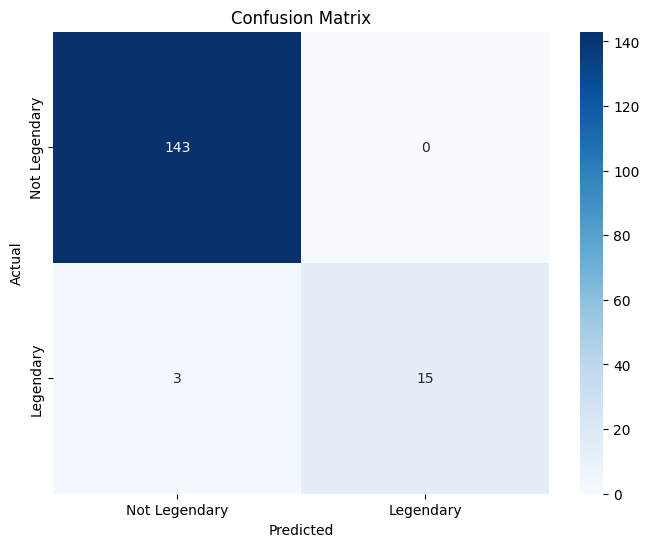

In [28]:
# Display accuracy score
lg_accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Logistic Regression Model Accuracy: {lg_accuracy*100:.2f}%")

# Display classification report
print(f"✅ Logistic Regression Model Classification Report:")
cr = classification_report(y_test, y_pred)
print(cr)

# Display confusion matrix
print(f"✅ Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Legendary', 'Legendary'], 
            yticklabels=['Not Legendary', 'Legendary'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Grid Search - Logistic Regression

In [ ]:
# Random Forrest hyper-parameters to optimize
lg_hparams = {
    'penalty': ['l1', 'l2', 'elasticnet'],
    'l1_ratio': [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
}

# Random Forrest model with default hyper-parameters
classifier = LogisticRegression(random_state=lg_random_state,
                                verbose=lg_verbose)

# cross validation without shuffle
cross_validator_no_shuffle = StratifiedKFold(n_splits=lg_grid_search_cv_folds,
                                             shuffle=False,
                                             random_state=None) # no random state because shuffle is False

# create grid search
lg_grid_search = GridSearchCV(classifier, 
                           lg_hparams, 
                           cv=cross_validator_no_shuffle, 
                           scoring=lg_grid_search_scoring, 
                           verbose=lg_grid_search_verbose,
                           n_jobs=-1) # multi-thread 

# grid search exploration
lg_grid_search.fit(preprocessor.fit_transform(X_train), y_train)

print(f"✅ Logistic Regression Grid Search completed: ")
print(f"    Best hyper parameters: {lg_grid_search.best_params_}")

# Select Best Random Forrest Model
best_rf_model = lg_grid_search.best_estimator_

best_lg_model_size = estimate_model_size(best_rf_model)
print(f"        Estimated size of Logistic Regression (GridSearch hyper parameters) model : {best_lg_model_size:.2f} Kb.")

# Define full pipleline with the best Logistic Regression model
best_lg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', best_rf_model)
])

/Users/laurent/Projects/projet-legendary-pokemon/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Users/laurent/Projects/projet-legendary-pokemon/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Users/laurent/Projects/projet-legendary-pokemon/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Users/laurent/Projects/projet-legendary-pokemon/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finishe

✅ Logistic Regression Grid Search completed: 
    Best hyper parameters: {'l1_ratio': 0.0, 'penalty': 'l2'}
        Estimated size of Logistic Regression (GridSearch hyper parameters) model : 6.76 Kb.


/Users/laurent/Projects/projet-legendary-pokemon/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


## Random Forrest Classification Model

### Train and predict

In [30]:
# Create Random Forrest model (default parameters)
rf_model = RandomForestClassifier(n_estimators=rf_n_estimators,
                                  max_depth=rf_max_depth,
                                  min_samples_split=rf_min_samples_split,
                                  random_state=rf_random_state, 
                                  verbose=rf_verbose)

# Create full pipleline with Random Forrest model
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', rf_model)
])
print(f"✅ Random Forrest training pipeline has been created.")

# train
rf_pipeline.fit(X_train, y_train)
print(f"✅ Random Forrest model has been trained using training dataset.")

rf_model_size = estimate_model_size(rf_model)
print(f"        Estimated size of Random Forrest (default hyper parameters) model : {rf_model_size:.2f} Kb.")

rf_depths = [estimator.tree_.max_depth for estimator in rf_model]
print(f"        Number of Trees : {len(rf_depths)}.")
print(f"        Max Depth : {np.max(rf_depths)}.")

# predict
y_pred = rf_pipeline.predict(X_test)
print(f"✅ Random Forrest prediction using test dataset completed.")

✅ Random Forrest training pipeline has been created.
✅ Random Forrest model has been trained using training dataset.
        Estimated size of Random Forrest (default hyper parameters) model : 561.86 Kb.
        Number of Trees : 100.
        Max Depth : 29.
✅ Random Forrest prediction using test dataset completed.


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.1s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.0s finished


### Evaluation

✅ Random Forrest Model Accuracy: 98.76%
✅ Random Forrest Model Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       143
           1       1.00      0.89      0.94        18

    accuracy                           0.99       161
   macro avg       0.99      0.94      0.97       161
weighted avg       0.99      0.99      0.99       161

✅ Confusion Matrix:


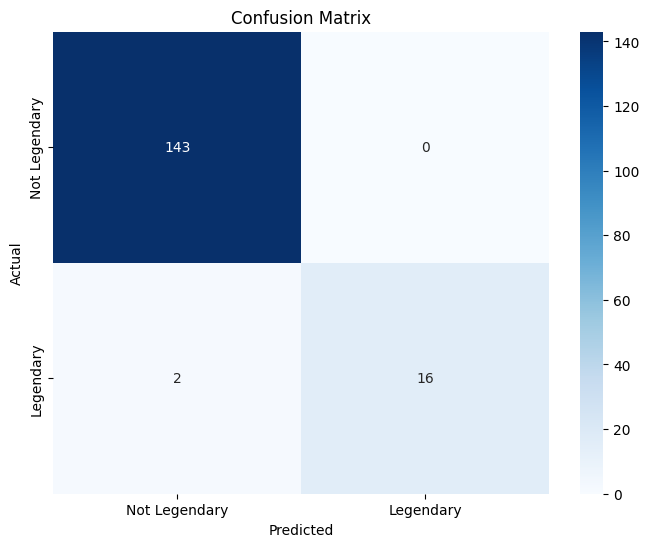

In [31]:
# Display accuracy score
rf_accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Random Forrest Model Accuracy: {rf_accuracy*100:.2f}%")

# Display classification report
print(f"✅ Random Forrest Model Classification Report:")
cr = classification_report(y_test, y_pred)
print(cr)

# Display confusion matrix
print(f"✅ Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Legendary', 'Legendary'], 
            yticklabels=['Not Legendary', 'Legendary'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Grid Search - Random Forrest 

In [32]:
# Random Forrest hyper-parameters to optimize
rf_hparams = {
    'n_estimators': [2, 5, 10, 20, 50, 100],
    'max_depth': [None, 2, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10, 15, 20]
}

# Random Forrest model with default hyper-parameters
classifier = RandomForestClassifier(random_state=rf_random_state,
                                    verbose=rf_verbose)

# cross validation without shuffle
cross_validator_no_shuffle = StratifiedKFold(n_splits=rf_grid_search_cv_folds,
                                             shuffle=False,
                                             random_state=None) # no random state because shuffle is False

# create grid search
rf_grid_search = GridSearchCV(classifier, 
                           rf_hparams, 
                           cv=cross_validator_no_shuffle, 
                           scoring=rf_grid_search_scoring, 
                           verbose=rf_grid_search_verbose,
                           n_jobs=-1) # multi-thread 

# grid search exploration
rf_grid_search.fit(preprocessor.fit_transform(X_train), y_train)

print(f"✅ Random Forrest Grid Search completed: ")
print(f"    Best hyper parameters: {rf_grid_search.best_params_}")

# Select Best Random Forrest Model
best_rf_model = rf_grid_search.best_estimator_

best_rf_model_size = estimate_model_size(best_rf_model)
print(f"        Estimated size of Random Forrest (GridSearch hyper parameters) model : {best_rf_model_size:.2f} Kb.")

best_rf_depths = [estimator.tree_.max_depth for estimator in best_rf_model]
print(f"        Number of Trees : {len(best_rf_depths)}.")
print(f"        Max Depth : {np.max(best_rf_depths)}.")

# Define full pipleline with the best Random Forrest model
best_rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', best_rf_model)
])

[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]

✅ Random Forrest Grid Search completed: 
    Best hyper parameters: {'max_depth': None, 'min_samples_split': 20, 'n_estimators': 5}
        Estimated size of Random Forrest (GridSearch hyper parameters) model : 17.29 Kb.
        Number of Trees : 5.
        Max Depth : 15.


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.0s finished


### Cross-validation - Grid Search Random Forrest

In [33]:
# no allow shuffling
cross_validator_shuffle = StratifiedKFold(n_splits=rf_grid_search_cv_folds, 
                                          shuffle=True, 
                                          random_state=rf_grid_search_random_state)

# cross validation results with best Random Forrest Model
cv_rf_scores = cross_val_score(best_rf_pipeline, 
                               X_train, y_train, 
                               cv=cross_validator_shuffle, 
                               scoring=rf_grid_search_scoring)

print(f"✅ Cross validation scores - Random Forrest : {cv_rf_scores}")
print(f"        Cross validation scores mean : {np.mean(cv_rf_scores)}")

✅ Cross validation scores - Random Forrest : [0.9765625 0.9609375 0.9921875 0.9609375 0.953125 ]
        Cross validation scores mean : 0.96875


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.0s finished


### Train and predict - Grid Search Random Forrest

In [34]:
# train best pipeline
best_rf_pipeline.fit(X_train, y_train)

# predict best pipeline
y_pred = best_rf_pipeline.predict(X_test)

[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.0s finished


### Evaluation - Grid Search Random Forrest 

✅ Random Forrest Best Model Accuracy: 98.14%
✅ Random Forrest Best Model Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       143
           1       1.00      0.83      0.91        18

    accuracy                           0.98       161
   macro avg       0.99      0.92      0.95       161
weighted avg       0.98      0.98      0.98       161

✅ Confusion Matrix:


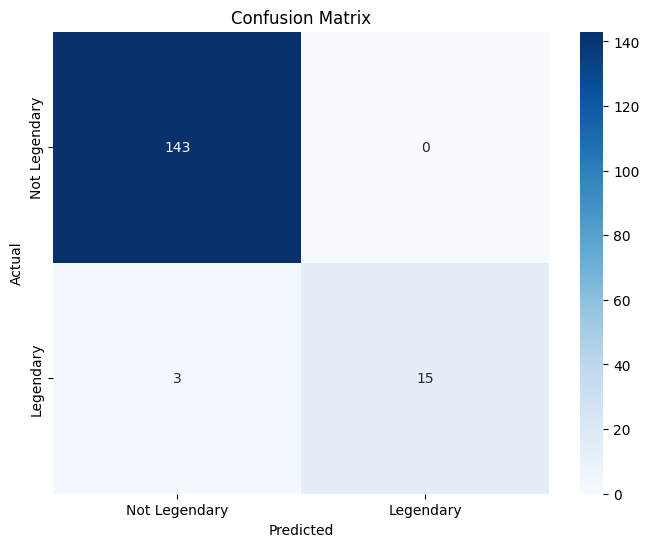

In [35]:
# Display accuracy score
best_rf_accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Random Forrest Best Model Accuracy: {best_rf_accuracy*100:.2f}%")

# Display classification report
print(f"✅ Random Forrest Best Model Classification Report:")
cr = classification_report(y_test, y_pred)
print(cr)

# Display confusion matrix
print(f"✅ Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Legendary', 'Legendary'], 
            yticklabels=['Not Legendary', 'Legendary'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## XGBoost Classification Model 

### Train and predict 

In [36]:
# create xgboost model
xgboost_model = GradientBoostingClassifier(random_state=xgboost_random_state,
                                           n_estimators=xgbost_n_estimators,
                                           max_depth=xg_boost_max_depth,
                                           min_samples_split=xgboost_min_samples_split,
                                           verbose=xgboost_verbose)

# full pipleline
xgboost_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgboost_model)
])
print(f"✅ XGBoost training pipeline has been created.")

# train pipeline with train dataset
xgboost_pipeline.fit(X_train, y_train)
print(f"✅ XGBoost model has been trained using training dataset.")

xgboost_model_size = estimate_model_size(xgboost_model)
print(f"        Estimated size of XGBoost (default hyper parameters) model : {xgboost_model_size:.2f} Kb.")

xgboost_depths = [tree.tree_.max_depth for stage in xgboost_model.estimators_ for tree in stage]
print(f"        Number of Trees : {len(xgboost_depths)}.")
print(f"        Max Depth : {np.max(xgboost_depths)}.")

# predict with test dataset 
y_pred = xgboost_pipeline.predict(X_test)
print(f"✅ XGBoost prediction using test dataset completed.")

✅ XGBoost training pipeline has been created.
      Iter       Train Loss   Remaining Time 
         1           0.3774            0.85s
         2           0.3127            0.90s
         3           0.2672            1.00s
         4           0.2318            0.83s
         5           0.2030            0.75s
         6           0.1790            0.67s
         7           0.1585            0.61s
         8           0.1409            0.56s
         9           0.1256            0.52s
        10           0.1121            0.51s
        20           0.0386            0.34s
        30           0.0139            0.27s
        40           0.0051            0.22s
        50           0.0019            0.18s
        60           0.0007            0.14s
        70           0.0003            0.10s
        80           0.0001            0.07s
        90           0.0000            0.03s
       100           0.0000            0.00s
✅ XGBoost model has been trained using training datas

### Evaluation

✅ XGBoost Model Accuracy: 100.00%
✅ XGBoost Model Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       143
           1       1.00      1.00      1.00        18

    accuracy                           1.00       161
   macro avg       1.00      1.00      1.00       161
weighted avg       1.00      1.00      1.00       161

✅ Confusion Matrix:


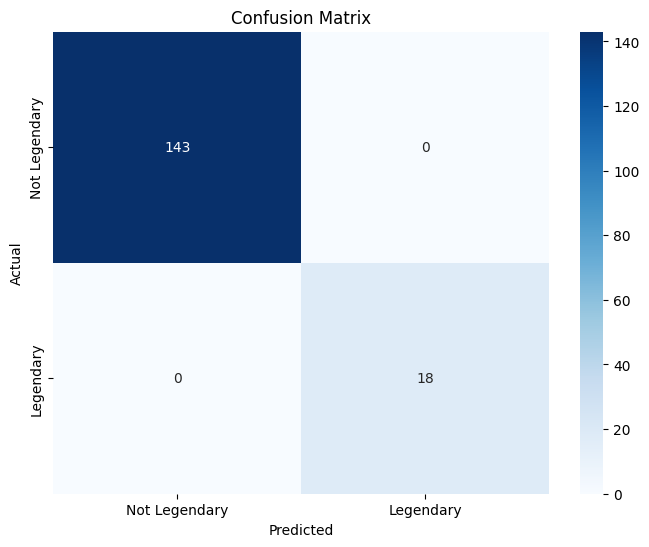

In [37]:
# Display accuracy score
xgboost_accuracy = accuracy_score(y_test, y_pred)
print(f"✅ XGBoost Model Accuracy: {xgboost_accuracy*100:.2f}%")

# Display classification report
print(f"✅ XGBoost Model Classification Report:")
cr = classification_report(y_test, y_pred)
print(cr)

# Display confusion matrix
print(f"✅ Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Legendary', 'Legendary'], 
            yticklabels=['Not Legendary', 'Legendary'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Grid Search - XGBoost 

In [38]:
# XGBoost hyper-parameters to optimize
xgboost_hparams = {
    'n_estimators': [2, 5, 10, 20, 50, 100],
    'max_depth': [None, 2, 3, 5, 10, 20],
    'min_samples_split': [2, 5, 10, 15, 20]
}

# XGBoost model with default hyper-parameters
xgboost_default_classifier = GradientBoostingClassifier(random_state=xgboost_random_state,
                                                        verbose=xgboost_verbose)

# create grid search
xgboost_grid_search = GridSearchCV(xgboost_default_classifier, 
                           xgboost_hparams, 
                           cv=cross_validator_no_shuffle, 
                           scoring=xgboost_grid_search_scoring, 
                           verbose=xgboost_grid_search_verbose,
                           n_jobs=-1) # multi-thread 

# grid search exploration
xgboost_grid_search.fit(preprocessor.fit_transform(X_train), y_train)

print(f"✅ XGBost Grid Search completed: ")
print(f"    Best hyper parameters: {xgboost_grid_search.best_params_}")

# Select Best XGBoost Model
best_xgboost_model = xgboost_grid_search.best_estimator_

best_xgboost_model_size = estimate_model_size(best_xgboost_model)
print(f"        Estimated size of XGBoost (GridSearch hyper parameters) model : {best_xgboost_model_size:.2f} Kb.")

best_xgboost_depths = [tree.tree_.max_depth for stage in best_xgboost_model.estimators_ for tree in stage]
print(f"        Number of Trees : {len(best_xgboost_depths)}.")
print(f"        Max Depth : {np.max(best_xgboost_depths)}.")

# Define full pipleline with the best Random Forrest model
best_xgboost_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', best_xgboost_model)
])

      Iter       Train Loss   Remaining Time       Iter       Train Loss   Remaining Time 

      Iter       Train Loss   Remaining Time 
         1           0.3811            0.00s
         1           0.3811            0.00s
         1           0.3811            0.00s
      Iter       Train Loss   Remaining Time 
         2           0.3158            0.00s
         2           0.3158            0.00s
      Iter       Train Loss   Remaining Time 
         2           0.3158            0.00s
      Iter       Train Loss   Remaining Time 
         1           0.3718            0.00s
      Iter       Train Loss   Remaining Time 
         1           0.3811            0.01s
      Iter       Train Loss   Remaining Time 
      Iter       Train Loss   Remaining Time 
         2           0.3081            0.00s
         1           0.3718            0.01s
         1           0.3811            0.02s
         1           0.3811            0.02s
         1           0.3718            0.02s
 

### Train and predict - Grid Search XGBoost

In [39]:
# train best XGBoost pipeline
best_xgboost_pipeline.fit(X_train, y_train)

# predict best XGBoost pipeline
y_pred = best_xgboost_pipeline.predict(X_test)

      Iter       Train Loss   Remaining Time 
         1           0.3774            0.14s
         2           0.3127            0.14s
         3           0.2672            0.13s
         4           0.2318            0.13s
         5           0.2030            0.12s
         6           0.1790            0.12s
         7           0.1585            0.12s
         8           0.1409            0.11s
         9           0.1256            0.11s
        10           0.1121            0.11s
        20           0.0386            0.08s
        30           0.0139            0.05s
        40           0.0051            0.03s
        50           0.0019            0.00s


### Evaluation - Grid Search XGBoost 

✅ Best XGBost Model Accuracy: 100.00%
✅ Best XGBoost Model Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       143
           1       1.00      1.00      1.00        18

    accuracy                           1.00       161
   macro avg       1.00      1.00      1.00       161
weighted avg       1.00      1.00      1.00       161

✅ Confusion Matrix:


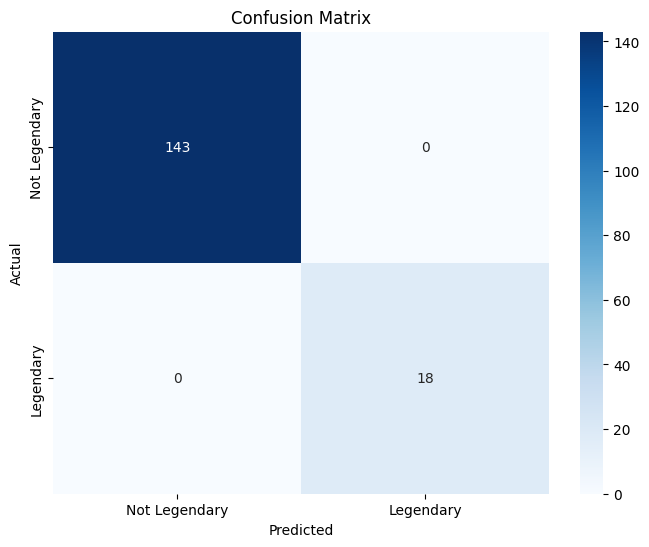

In [40]:
# Display accuracy score
best_xgboost_accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Best XGBost Model Accuracy: {xgboost_accuracy*100:.2f}%")

# Display classification report
print(f"✅ Best XGBoost Model Classification Report:")
cr = classification_report(y_test, y_pred)
print(cr)

# Display confusion matrix
print(f"✅ Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Legendary', 'Legendary'], 
            yticklabels=['Not Legendary', 'Legendary'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()